# Wikipedia Bot Detection — XGBoost Model Training

Trains a binary classifier predicting whether a Wikipedia edit was made by a bot (`bot=True`).
Input: raw CSV batches collected by `consumer_offline_batch.py` from the `wikipedia-raw` Kafka topic.
Features: produced by the shared `feature_engineering.py` module (guarantees consistency with streaming inference).

## 1. Imports & Config

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, accuracy_score, classification_report,
    confusion_matrix, RocCurveDisplay, PrecisionRecallDisplay,
)

ROOT = Path('../').resolve()
sys.path.insert(0, str(ROOT / 'src'))
from feature_engineering import WikipediaFeatureEngineer

DATA_DIR   = ROOT / 'data'
MODEL_DIR  = ROOT / 'models'
MODEL_DIR.mkdir(exist_ok=True)
MODEL_PATH = MODEL_DIR / 'xgb_bot_detector.json'

RANDOM_STATE = 42
TEST_SIZE    = 0.2


## 2. Load All CSV Batches

In [2]:
csv_files = sorted(DATA_DIR.glob('*.csv'))
print(f'Found {len(csv_files)} CSV file(s):')
for f in csv_files:
    print(f'  {f.name}')

raw_df = pd.concat(
    [pd.read_csv(f, low_memory=False) for f in csv_files],
    ignore_index=True,
)
print(f'Total rows: {len(raw_df):,}  |  Columns: {list(raw_df.columns)}')


Found 20 CSV file(s):
  wikipedia_raw_0000_20260604T165009.csv
  wikipedia_raw_0001_20260604T170553.csv
  wikipedia_raw_0002_20260604T172205.csv
  wikipedia_raw_0003_20260604T173816.csv
  wikipedia_raw_0004_20260604T175530.csv
  wikipedia_raw_0005_20260604T181406.csv
  wikipedia_raw_0006_20260604T182906.csv
  wikipedia_raw_0007_20260604T184434.csv
  wikipedia_raw_0008_20260604T190832.csv
  wikipedia_raw_0009_20260604T192410.csv
  wikipedia_raw_0010_20260604T194112.csv
  wikipedia_raw_0011_20260604T195755.csv
  wikipedia_raw_0012_20260604T200823.csv
  wikipedia_raw_0013_20260604T202240.csv
  wikipedia_raw_0014_20260604T203900.csv
  wikipedia_raw_0015_20260604T205345.csv
  wikipedia_raw_0016_20260604T210304.csv
  wikipedia_raw_0017_20260604T212043.csv
  wikipedia_raw_0018_20260604T214122.csv
  wikipedia_raw_0019_20260604T220342.csv
Total rows: 100,000  |  Columns: ['id', 'type', 'namespace', 'title', 'comment', 'parsedcomment', 'timestamp', 'user', 'bot', 'minor', 'patrolled', 'server_na

## 3. Exploratory Data Analysis

In [3]:
print('=== Missing values ===')
miss = raw_df.isnull().sum()
print(miss[miss > 0].to_string())
print('\n=== Dtypes ===')
print(raw_df.dtypes.to_string())

=== Missing values ===
id                2709
comment           9440
parsedcomment     9440
minor            51983
patrolled        96932
length_old       55051
length_new       51983
revision_old     55051
revision_new     51983

=== Dtypes ===
id               float64
type                 str
namespace          int64
title                str
comment              str
parsedcomment        str
timestamp          int64
user                 str
bot                 bool
minor             object
patrolled         object
server_name          str
wiki                 str
length_old       float64
length_new       float64
revision_old     float64
revision_new     float64


Target distribution:
  Human (0): 93,646  (93.6%)
  Bot (1): 6,354  (6.4%)


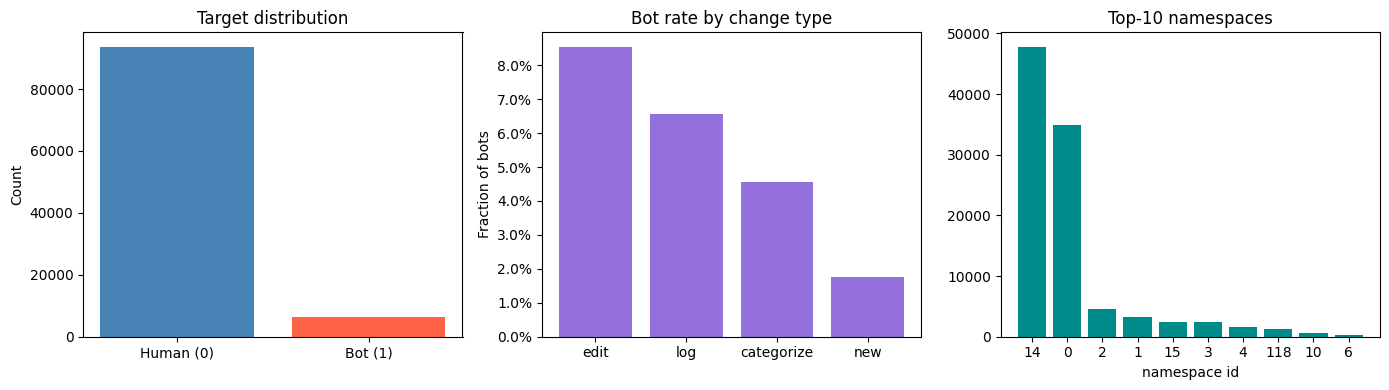

In [4]:
bot_counts = raw_df['bot'].astype(int).value_counts().sort_index()
labels = ['Human (0)', 'Bot (1)']
print('Target distribution:')
for k, v in zip(labels, bot_counts):
    print(f'  {k}: {v:,}  ({v/len(raw_df)*100:.1f}%)')

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].bar(labels, bot_counts.values, color=['steelblue', 'tomato'])
axes[0].set_title('Target distribution'); axes[0].set_ylabel('Count')
type_bot = raw_df.groupby('type')['bot'].mean().sort_values(ascending=False)
axes[1].bar(type_bot.index, type_bot.values, color='mediumpurple')
axes[1].set_title('Bot rate by change type'); axes[1].set_ylabel('Fraction of bots')
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ns_counts = raw_df['namespace'].value_counts().head(10)
axes[2].bar(ns_counts.index.astype(str), ns_counts.values, color='darkcyan')
axes[2].set_title('Top-10 namespaces'); axes[2].set_xlabel('namespace id')
plt.tight_layout(); plt.show()

## 4. Feature Engineering

Uses `WikipediaFeatureEngineer` from `src/feature_engineering.py` — **the same module used during live inference** — to guarantee identical transformations.

- Drops `bot`, `user`, `id` (prevents data leakage)
- Derives edit features: `has_length`, `length_diff`, `is_minor`, `hour_of_day`, ...
- One-hot encodes `type` (edit/new/log/categorize) and `namespace`
- Feature-hashes text fields: `wiki`, `server_name`, `comment`, `parsedcomment`

In [5]:
fe = WikipediaFeatureEngineer()
y = raw_df['bot'].astype(int)
X = fe.transform_df(raw_df.copy())

print(f'Feature matrix shape: {X.shape}')
print(f'NaN in X: {X.isnull().sum().sum()}  (handled natively by XGBoost)')
print(f'Target positives (bot=1): {y.sum():,} / {len(y):,}  ({y.mean()*100:.1f}%)')

Feature matrix shape: (100000, 303)
NaN in X: 379255  (handled natively by XGBoost)
Target positives (bot=1): 6,354 / 100,000  (6.4%)


In [6]:
pd.set_option('display.max_columns', None)
X

,length_old,length_new,revision_old,revision_new,has_length,has_revision,length_diff,length_diff_abs,length_ratio,is_new_page,is_minor,is_patrolled,comment_length,has_comment,title_has_number,hour_of_day,type_edit,type_new,type_log,type_categorize,ns_article,ns_book,ns_book_talk,ns_category,ns_category_talk,ns_draft,ns_draft_talk,ns_education_program,ns_file,ns_file_talk,ns_help,ns_help_talk,ns_mediawiki,ns_mediawiki_talk,ns_module,ns_module_talk,ns_portal,ns_portal_talk,ns_talk,ns_template,ns_template_talk,ns_timedtext,ns_user,ns_user_talk,ns_wikipedia,ns_wikipedia_talk,ns_other,hash_wiki_0,hash_wiki_1,hash_wiki_2,hash_wiki_3,hash_wiki_4,hash_wiki_5,hash_wiki_6,hash_wiki_7,hash_wiki_8,hash_wiki_9,hash_wiki_10,hash_wiki_11,hash_wiki_12,hash_wiki_13,hash_wiki_14,hash_wiki_15,hash_wiki_16,hash_wiki_17,hash_wiki_18,hash_wiki_19,hash_wiki_20,hash_wiki_21,hash_wiki_22,hash_wiki_23,hash_wiki_24,hash_wiki_25,hash_wiki_26,hash_wiki_27,hash_wiki_28,hash_wiki_29,hash_wiki_30,hash_wiki_31,hash_wiki_32,hash_wiki_33,hash_wiki_34,hash_wiki_35,hash_wiki_36,hash_wiki_37,hash_wiki_38,hash_wiki_39,hash_wiki_40,hash_wiki_41,hash_wiki_42,hash_wiki_43,hash_wiki_44,hash_wiki_45,hash_wiki_46,hash_wiki_47,hash_wiki_48,hash_wiki_49,hash_wiki_50,hash_wiki_51,hash_wiki_52,hash_wiki_53,hash_wiki_54,hash_wiki_55,hash_wiki_56,hash_wiki_57,hash_wiki_58,hash_wiki_59,hash_wiki_60,hash_wiki_61,hash_wiki_62,hash_wiki_63,hash_server_name_0,hash_server_name_1,hash_server_name_2,hash_server_name_3,hash_server_name_4,hash_server_name_5,hash_server_name_6,hash_server_name_7,hash_server_name_8,hash_server_name_9,hash_server_name_10,hash_server_name_11,hash_server_name_12,hash_server_name_13,hash_server_name_14,hash_server_name_15,hash_server_name_16,hash_server_name_17,hash_server_name_18,hash_server_name_19,hash_server_name_20,hash_server_name_21,hash_server_name_22,hash_server_name_23,hash_server_name_24,hash_server_name_25,hash_server_name_26,hash_server_name_27,hash_server_name_28,hash_server_name_29,hash_server_name_30,hash_server_name_31,hash_server_name_32,hash_server_name_33,hash_server_name_34,hash_server_name_35,hash_server_name_36,hash_server_name_37,hash_server_name_38,hash_server_name_39,hash_server_name_40,hash_server_name_41,hash_server_name_42,hash_server_name_43,hash_server_name_44,hash_server_name_45,hash_server_name_46,hash_server_name_47,hash_server_name_48,hash_server_name_49,hash_server_name_50,hash_server_name_51,hash_server_name_52,hash_server_name_53,hash_server_name_54,hash_server_name_55,hash_server_name_56,hash_server_name_57,hash_server_name_58,hash_server_name_59,hash_server_name_60,hash_server_name_61,hash_server_name_62,hash_server_name_63,hash_comment_0,hash_comment_1,hash_comment_2,hash_comment_3,hash_comment_4,hash_comment_5,hash_comment_6,hash_comment_7,hash_comment_8,hash_comment_9,hash_comment_10,hash_comment_11,hash_comment_12,hash_comment_13,hash_comment_14,hash_comment_15,hash_comment_16,hash_comment_17,hash_comment_18,hash_comment_19,hash_comment_20,hash_comment_21,hash_comment_22,hash_comment_23,hash_comment_24,hash_comment_25,hash_comment_26,hash_comment_27,hash_comment_28,hash_comment_29,hash_comment_30,hash_comment_31,hash_comment_32,hash_comment_33,hash_comment_34,hash_comment_35,hash_comment_36,hash_comment_37,hash_comment_38,hash_comment_39,hash_comment_40,hash_comment_41,hash_comment_42,hash_comment_43,hash_comment_44,hash_comment_45,hash_comment_46,hash_comment_47,hash_comment_48,hash_comment_49,hash_comment_50,hash_comment_51,hash_comment_52,hash_comment_53,hash_comment_54,hash_comment_55,hash_comment_56,hash_comment_57,hash_comment_58,hash_comment_59,hash_comment_60,hash_comment_61,hash_comment_62,hash_comment_63,hash_parsedcomment_0,hash_parsedcomment_1,hash_parsedcomment_2,hash_parsedcomment_3,hash_parsedcomment_4,hash_parsedcomment_5,hash_parsedcomment_6,hash_parsedcomment_7,hash_parsedcomment_8,hash_parsedcomment_9,hash_parsedcomment_10,hash_parsedcomment_11,hash_parsedcomment_12,hash_parsedcomment_13,hash_pars

In [7]:
# --- has_length vs bot rate (full 100k dataset) ---

def gini(p):
    return 1 - p**2 - (1 - p)**2

analysis = pd.DataFrame({'has_length': X['has_length'], 'bot': y})
grp = analysis.groupby('has_length')['bot'].agg(['mean', 'sum', 'count'])
grp.columns = ['bot_rate', 'bot_count', 'total_count']

overall_rate = y.mean()
n_total = len(y)

print(f'=== has_length vs bot rate (n={n_total:,}) ===')
print(f"{'has_length':<14} {'total':>8} {'bots':>8} {'bot_rate':>10} {'vs baseline':>13}")
for hl_val, row in grp.iterrows():
    ratio = row['bot_rate'] / overall_rate
    print(f"  {hl_val:<12} {int(row['total_count']):>8,} {int(row['bot_count']):>8,} "
          f"{row['bot_rate']*100:>9.2f}%  {ratio:>10.2f}x")
print(f"  {'OVERALL':<12} {n_total:>8,} {int(y.sum()):>8,} {overall_rate*100:>9.2f}%  {'1.00x':>10}")

# Gini impurity gain for a single binary split on has_length
gini_before = gini(overall_rate)
n0, n1 = grp.loc[0, 'total_count'], grp.loc[1, 'total_count']
p0, p1 = grp.loc[0, 'bot_rate'],   grp.loc[1, 'bot_rate']
gini_after = (n0 / n_total) * gini(p0) + (n1 / n_total) * gini(p1)
gini_gain  = gini_before - gini_after

print(f'\n=== Gini gain dla podziału has_length ===')
print(f'  Gini przed podziałem : {gini_before:.6f}')
print(f'  Gini po podziale     : {gini_after:.6f}')
print(f'  Gini gain            : {gini_gain:.6f}  ({gini_gain / gini_before * 100:.2f}% redukcja)')
print(f'\nDla porównania — gdyby perfect split (jedna gałąź czysto boty):')
p_ref = y.sum() / n_total
gini_perfect = (1 - p_ref) * gini(0) + p_ref * gini(1)
print(f'  Gini gain max możliwy: {gini_before - gini_perfect:.6f}')

=== has_length vs bot rate (n=100,000) ===
has_length        total     bots   bot_rate   vs baseline
  0              55,051    2,515      4.57%        0.72x
  1              44,949    3,839      8.54%        1.34x
  OVERALL       100,000    6,354      6.35%       1.00x

=== Gini gain dla podziału has_length ===
  Gini przed podziałem : 0.119005
  Gini po podziale     : 0.118224
  Gini gain            : 0.000781  (0.66% redukcja)

Dla porównania — gdyby perfect split (jedna gałąź czysto boty):
  Gini gain max możliwy: 0.119005


## 5. Train / Validation Split

In [8]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)
print(f'Train: {X_train.shape[0]:,} rows  |  Val: {X_val.shape[0]:,} rows')
print(f'Bot rate - train: {y_train.mean()*100:.1f}%  |  val: {y_val.mean()*100:.1f}%')

neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos_weight = neg / pos
print(f'scale_pos_weight = {neg}/{pos} = {scale_pos_weight:.1f}')

Train: 80,000 rows  |  Val: 20,000 rows
Bot rate - train: 6.4%  |  val: 6.4%
scale_pos_weight = 74917/5083 = 14.7


## 6. Hyperparameter Search — 20 Variants

Each variant tests a different combination of hyperparameters.
For every model we record:
- **train_acc / val_acc** — accuracy on train vs validation set
- **acc_gap** = train_acc − val_acc — overfitting measured by accuracy
- **train_auc / val_auc** — ROC-AUC on train vs validation set
- **auc_gap** = train_auc − val_auc — overfitting measured by AUC (primary metric)

Ideal model: **high val_auc** + **small auc_gap** (top-left of the scatter plot).

In [9]:
PARAM_GRID = [
    # V01 - Baseline
    {'n_estimators': 200, 'max_depth':  4, 'learning_rate': 0.10, 'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_weight':  1, 'reg_alpha':  0,  'reg_lambda':  1, 'gamma': 0},
    # V02 - Very shallow trees (underfitting risk)
    {'n_estimators': 300, 'max_depth':  2, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_weight':  1, 'reg_alpha':  0,  'reg_lambda':  1, 'gamma': 0},
    # V03 - Shallow trees
    {'n_estimators': 300, 'max_depth':  3, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_weight':  1, 'reg_alpha':  0,  'reg_lambda':  1, 'gamma': 0},
    # V04 - Deep trees (overfit risk)
    {'n_estimators': 300, 'max_depth':  8, 'learning_rate': 0.10, 'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_weight':  1, 'reg_alpha':  0,  'reg_lambda':  1, 'gamma': 0},
    # V05 - Very deep, no subsampling (max overfit)
    {'n_estimators': 300, 'max_depth': 10, 'learning_rate': 0.10, 'subsample': 1.0, 'colsample_bytree': 1.0, 'min_child_weight':  1, 'reg_alpha':  0,  'reg_lambda':  1, 'gamma': 0},
    # V06 - High learning rate
    {'n_estimators': 100, 'max_depth':  5, 'learning_rate': 0.30, 'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_weight':  1, 'reg_alpha':  0,  'reg_lambda':  1, 'gamma': 0},
    # V07 - Low learning rate, many trees
    {'n_estimators': 500, 'max_depth':  5, 'learning_rate': 0.01, 'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_weight':  1, 'reg_alpha':  0,  'reg_lambda':  1, 'gamma': 0},
    # V08 - Heavy subsampling
    {'n_estimators': 300, 'max_depth':  5, 'learning_rate': 0.05, 'subsample': 0.5, 'colsample_bytree': 0.5, 'min_child_weight':  1, 'reg_alpha':  0,  'reg_lambda':  1, 'gamma': 0},
    # V09 - No subsampling
    {'n_estimators': 200, 'max_depth':  5, 'learning_rate': 0.10, 'subsample': 1.0, 'colsample_bytree': 1.0, 'min_child_weight':  1, 'reg_alpha':  0,  'reg_lambda':  1, 'gamma': 0},
    # V10 - L1 regularization moderate
    {'n_estimators': 300, 'max_depth':  5, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_weight':  1, 'reg_alpha':  5,  'reg_lambda':  1, 'gamma': 0},
    # V11 - L1 regularization strong
    {'n_estimators': 300, 'max_depth':  5, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_weight':  1, 'reg_alpha': 10,  'reg_lambda':  1, 'gamma': 0},
    # V12 - L2 regularization moderate
    {'n_estimators': 300, 'max_depth':  5, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_weight':  1, 'reg_alpha':  0,  'reg_lambda': 10, 'gamma': 0},
    # V13 - L2 regularization strong
    {'n_estimators': 300, 'max_depth':  5, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_weight':  1, 'reg_alpha':  0,  'reg_lambda': 50, 'gamma': 0},
    # V14 - High min_child_weight
    {'n_estimators': 300, 'max_depth':  6, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_weight': 10, 'reg_alpha':  0,  'reg_lambda':  1, 'gamma': 0},
    # V15 - Very high min_child_weight
    {'n_estimators': 300, 'max_depth':  6, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_weight': 30, 'reg_alpha':  0,  'reg_lambda':  1, 'gamma': 0},
    # V16 - Balanced combo: medium depth + all regularization types
    {'n_estimators': 400, 'max_depth':  4, 'learning_rate': 0.05, 'subsample': 0.7, 'colsample_bytree': 0.7, 'min_child_weight':  5, 'reg_alpha':0.5,  'reg_lambda':  5, 'gamma': 0},
    # V17 - Balanced combo: medium depth + L1+L2
    {'n_estimators': 400, 'max_depth':  5, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_weight':  5, 'reg_alpha':  1,  'reg_lambda':  5, 'gamma': 0},
    # V18 - Aggressive subsampling + regularization
    {'n_estimators': 200, 'max_depth':  4, 'learning_rate': 0.10, 'subsample': 0.6, 'colsample_bytree': 0.6, 'min_child_weight':  5, 'reg_alpha':  1,  'reg_lambda':  3, 'gamma': 0},
    # V19 - Gamma pruning (min loss reduction required to split)
    {'n_estimators': 300, 'max_depth':  6, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_weight':  1, 'reg_alpha':  0,  'reg_lambda':  1, 'gamma': 5},
    # V20 - Mixed: gamma + L1 + L2 + min_child_weight
    {'n_estimators': 300, 'max_depth':  6, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_weight':  3, 'reg_alpha':  1,  'reg_lambda':  5, 'gamma': 2},
]
print(f'{len(PARAM_GRID)} variants defined')

20 variants defined


In [10]:
results = []

for i, params in enumerate(PARAM_GRID):
    print(f'Training V{i+1:02d}/20 ...', end=' ', flush=True)
    m = xgb.XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=0,
        **params,
    )
    m.fit(X_train, y_train)

    train_prob = m.predict_proba(X_train)[:, 1]
    val_prob   = m.predict_proba(X_val)[:, 1]
    train_acc  = accuracy_score(y_train, m.predict(X_train))
    val_acc    = accuracy_score(y_val,   m.predict(X_val))
    train_auc  = roc_auc_score(y_train, train_prob)
    val_auc    = roc_auc_score(y_val,   val_prob)

    results.append({
        'variant':  f'V{i+1:02d}',
        'n_est':    params['n_estimators'],
        'depth':    params['max_depth'],
        'lr':       params['learning_rate'],
        'sub':      params['subsample'],
        'col':      params['colsample_bytree'],
        'mcw':      params['min_child_weight'],
        'alpha':    params['reg_alpha'],
        'lambda_':  params['reg_lambda'],
        'gamma':    params['gamma'],
        'train_acc': round(train_acc, 4),
        'val_acc':   round(val_acc,   4),
        'acc_gap':   round(train_acc - val_acc, 4),
        'train_auc': round(train_auc, 4),
        'val_auc':   round(val_auc,   4),
        'auc_gap':   round(train_auc - val_auc, 4),
        '_model': m,
    })
    print(f'val_AUC={val_auc:.4f}  acc_gap={train_acc - val_acc:+.4f}  auc_gap={train_auc - val_auc:+.4f}')

print('All 20 variants trained.')

Training V01/20 ... val_AUC=0.9789  acc_gap=+0.0046  auc_gap=+0.0060
Training V02/20 ... val_AUC=0.9555  acc_gap=+0.0012  auc_gap=+0.0013
Training V03/20 ... val_AUC=0.9706  acc_gap=+0.0014  auc_gap=+0.0029
Training V04/20 ... val_AUC=0.9877  acc_gap=+0.0098  auc_gap=+0.0106
Training V05/20 ... val_AUC=0.9872  acc_gap=+0.0113  auc_gap=+0.0111
Training V06/20 ... val_AUC=0.9840  acc_gap=+0.0086  auc_gap=+0.0085
Training V07/20 ... val_AUC=0.9742  acc_gap=+0.0026  auc_gap=+0.0033
Training V08/20 ... val_AUC=0.9813  acc_gap=+0.0047  auc_gap=+0.0061
Training V09/20 ... val_AUC=0.9820  acc_gap=+0.0051  auc_gap=+0.0071
Training V10/20 ... val_AUC=0.9813  acc_gap=+0.0047  auc_gap=+0.0060
Training V11/20 ... val_AUC=0.9809  acc_gap=+0.0044  auc_gap=+0.0055
Training V12/20 ... val_AUC=0.9809  acc_gap=+0.0048  auc_gap=+0.0058
Training V13/20 ... val_AUC=0.9793  acc_gap=+0.0046  auc_gap=+0.0048
Training V14/20 ... val_AUC=0.9836  acc_gap=+0.0043  auc_gap=+0.0065
Training V15/20 ... val_AUC=0.9819

## 7. Results — Comparison Table & Plots

In [11]:
cols_show = ['variant','n_est','depth','lr','sub','col','mcw','alpha','lambda_','gamma',
             'train_acc','val_acc','acc_gap','train_auc','val_auc','auc_gap']
results_df = pd.DataFrame([{k: v for k, v in r.items() if k != '_model'} for r in results])
results_df_sorted = results_df.sort_values('val_auc', ascending=False).reset_index(drop=True)
results_df_sorted.index += 1

float_cols = ['train_acc','val_acc','acc_gap','train_auc','val_auc','auc_gap']
display(
    results_df_sorted[cols_show].style
        .background_gradient(subset=['val_auc', 'train_auc'], cmap='Greens')
        .background_gradient(subset=['acc_gap', 'auc_gap'],   cmap='RdYlGn_r')
        .format({c: '{:.4f}' for c in float_cols})
)

,variant,n_est,depth,lr,sub,col,mcw,alpha,lambda_,gamma,train_acc,val_acc,acc_gap,train_auc,val_auc,auc_gap
1,V04,300,8,0.100000,0.800000,0.800000,1,0.000000,1,0,0.9697,0.9598,0.0098,0.9983,0.9877,0.0106
2,V05,300,10,0.100000,1.000000,1.000000,1,0.000000,1,0,0.9660,0.9547,0.0113,0.9983,0.9872,0.0111
3,V19,300,6,0.050000,0.800000,0.800000,1,0.000000,1,5,0.9385,0.9344,0.0042,0.9916,0.9845,0.0071
4,V06,100,5,0.300000,0.800000,0.800000,1,0.000000,1,0,0.9406,0.9319,0.0086,0.9926,0.9840,0.0085
5,V20,300,6,0.050000,0.800000,0.800000,3,1.000000,5,2,0.9335,0.9303,0.0032,0.9905,0.9839,0.0066
6,V14,300,6,0.050000,0.800000,0.800000,10,0.000000,1,0,0.9338,0.9295,0.0043,0.9901,0.9836,0.0065
7,V17,400,5,0.050000,0.800000,0.800000,5,1.000000,5,0,0.9348,0.9304,0.0044,0.9889,0.9828,0.0061
8,V09,200,5,0.100000,1.000000,1.000000,1,0.000000,1,0,0.9351,0.9300,0.0051,0.9890,0.9820,0.0071
9,V15,300,6,0.050000,0.800000,0.800000,30,0.000000,1,0,0.9302,0.9261,0.0041,0.9877,0.9819,0.0058
10,V08,300,5,0.050000,0.500000,0.500000,1,0.000000,1,0,0.9289,0.9242,0.0047,0.9874,0.9813,0.0061


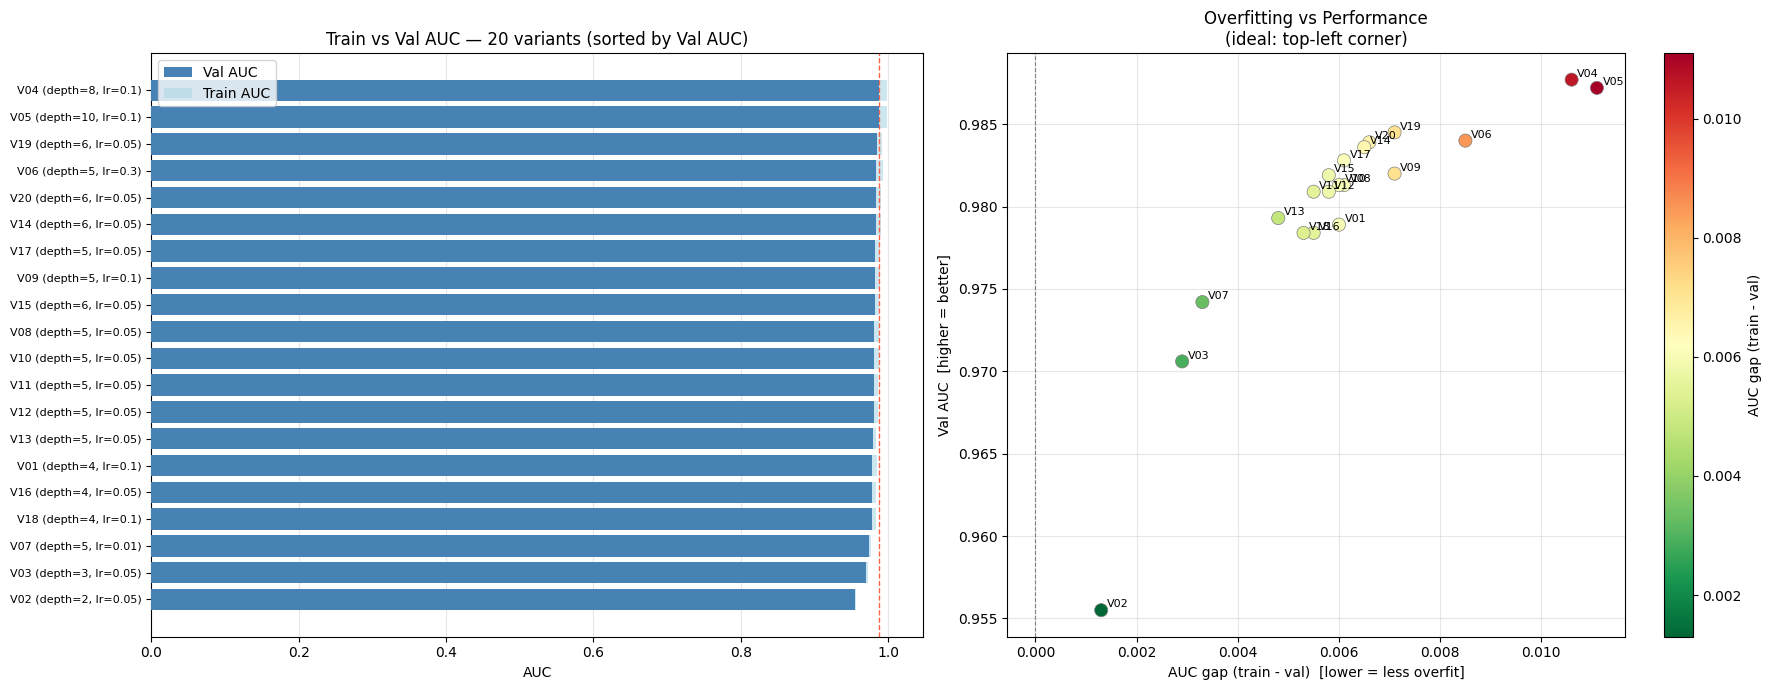

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Left: Train vs Val AUC for all 20 variants
rd = results_df_sorted
y_pos = list(range(len(rd)))
axes[0].barh(y_pos, rd['val_auc'],   color='steelblue', label='Val AUC',   zorder=3)
axes[0].barh(y_pos, rd['train_auc'], color='lightblue', alpha=0.6, label='Train AUC', zorder=2)
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(
    [f"{row['variant']} (depth={row['depth']}, lr={row['lr']})" for _, row in rd.iterrows()],
    fontsize=8
)
axes[0].invert_yaxis()
axes[0].set_xlabel('AUC')
axes[0].set_title('Train vs Val AUC — 20 variants (sorted by Val AUC)')
axes[0].legend()
axes[0].axvline(rd['val_auc'].max(), color='tomato', ls='--', lw=1)
axes[0].grid(axis='x', alpha=0.3)

# Right: Scatter val_auc vs auc_gap (ideal = top-left)
sc = axes[1].scatter(
    rd['auc_gap'], rd['val_auc'],
    c=rd['auc_gap'], cmap='RdYlGn_r', s=90, zorder=3, edgecolors='gray', linewidths=0.5
)
plt.colorbar(sc, ax=axes[1], label='AUC gap (train - val)')
for _, row in rd.iterrows():
    axes[1].annotate(row['variant'], (row['auc_gap'], row['val_auc']),
                     fontsize=8, xytext=(4, 2), textcoords='offset points')
axes[1].set_xlabel('AUC gap (train - val)  [lower = less overfit]')
axes[1].set_ylabel('Val AUC  [higher = better]')
axes[1].set_title('Overfitting vs Performance\n(ideal: top-left corner)')
axes[1].axvline(0, color='gray', ls='--', lw=0.8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

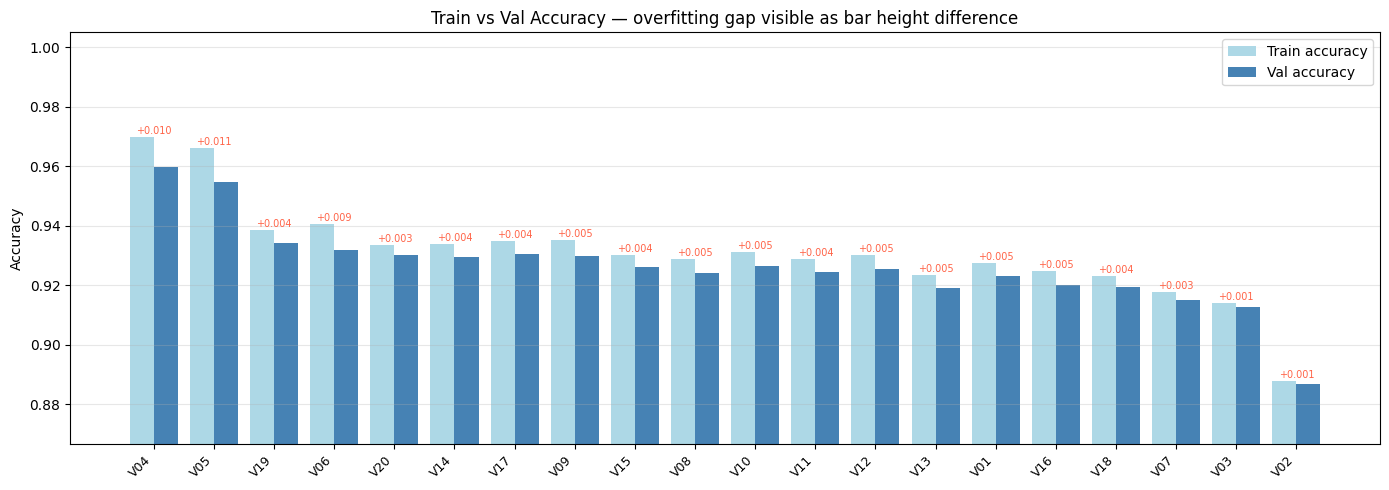

In [13]:
# Accuracy gap side-by-side bar chart
fig, ax = plt.subplots(figsize=(14, 5))
rd2 = results_df_sorted.reset_index(drop=True)
x = list(range(len(rd2)))
ax.bar([i - 0.2 for i in x], rd2['train_acc'], width=0.4, label='Train accuracy', color='lightblue')
ax.bar([i + 0.2 for i in x], rd2['val_acc'],   width=0.4, label='Val accuracy',   color='steelblue')
ax.set_xticks(x)
ax.set_xticklabels(rd2['variant'], rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Accuracy')
ax.set_title('Train vs Val Accuracy — overfitting gap visible as bar height difference')
ax.legend()
ax.set_ylim(rd2['val_acc'].min() - 0.02, 1.005)
ax.grid(axis='y', alpha=0.3)
for i, row in rd2.iterrows():
    ax.text(i, max(row['train_acc'], row['val_acc']) + 0.001,
            f"+{row['acc_gap']:.3f}", ha='center', fontsize=7, color='tomato')
plt.tight_layout()
plt.show()

## 8. Best Model Selection

Selection criterion: **highest val_auc penalised by half the auc_gap**.
Balances predictive power with generalisation — a model 0.01 better on AUC
but 0.05 more overfit is not preferred.

```
score = val_auc - 0.5 * auc_gap
```

In [14]:
results_df_sorted['score'] = results_df_sorted['val_auc'] - 0.5 * results_df_sorted['auc_gap']
best_row = results_df_sorted.loc[results_df_sorted['score'].idxmax()]
best_variant = best_row['variant']
best_model = next(r['_model'] for r in results if r['variant'] == best_variant)

print(f'=== Best variant: {best_variant} ===')
print(f'  Val AUC   : {best_row["val_auc"]:.4f}')
print(f'  Train AUC : {best_row["train_auc"]:.4f}')
print(f'  AUC gap   : {best_row["auc_gap"]:.4f}')
print(f'  Val Acc   : {best_row["val_acc"]:.4f}')
print(f'  Train Acc : {best_row["train_acc"]:.4f}')
print(f'  Acc gap   : {best_row["acc_gap"]:.4f}')
print(f'  Score     : {best_row["score"]:.4f}')
print()
print('Hyperparameters:')
for k in ['n_est','depth','lr','sub','col','mcw','alpha','lambda_','gamma']:
    print(f'  {k:8s}: {best_row[k]}')

=== Best variant: V04 ===
  Val AUC   : 0.9877
  Train AUC : 0.9983
  AUC gap   : 0.0106
  Val Acc   : 0.9598
  Train Acc : 0.9697
  Acc gap   : 0.0098
  Score     : 0.9824

Hyperparameters:
  n_est   : 300
  depth   : 8
  lr      : 0.1
  sub     : 0.8
  col     : 0.8
  mcw     : 1
  alpha   : 0.0
  lambda_ : 1
  gamma   : 0


## 9. Best Model — Detailed Evaluation

In [15]:
y_prob = best_model.predict_proba(X_val)[:, 1]
y_pred = best_model.predict(X_val)
roc_auc = roc_auc_score(y_val, y_prob)

print(f'ROC-AUC: {roc_auc:.4f}')
print()
print(classification_report(y_val, y_pred, target_names=['human', 'bot']))

ROC-AUC: 0.9877

              precision    recall  f1-score   support

       human       0.99      0.96      0.98     18729
         bot       0.63      0.91      0.74      1271

    accuracy                           0.96     20000
   macro avg       0.81      0.94      0.86     20000
weighted avg       0.97      0.96      0.96     20000



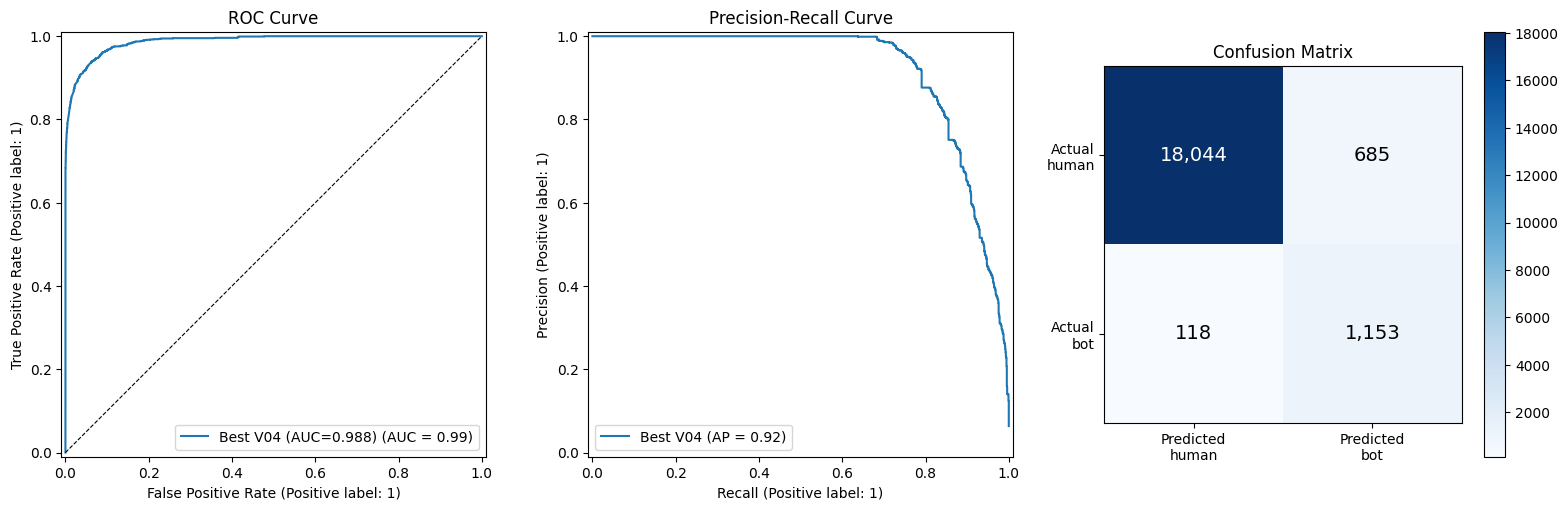

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

RocCurveDisplay.from_predictions(y_val, y_prob, ax=axes[0],
                                  name=f'Best {best_variant} (AUC={roc_auc:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', lw=0.8)
axes[0].set_title('ROC Curve')

PrecisionRecallDisplay.from_predictions(y_val, y_prob, ax=axes[1], name=f'Best {best_variant}')
axes[1].set_title('Precision-Recall Curve')

cm = confusion_matrix(y_val, y_pred)
im = axes[2].imshow(cm, cmap='Blues')
axes[2].set_xticks([0, 1]); axes[2].set_yticks([0, 1])
axes[2].set_xticklabels(['Predicted\nhuman', 'Predicted\nbot'])
axes[2].set_yticklabels(['Actual\nhuman', 'Actual\nbot'])
axes[2].set_title('Confusion Matrix')
for i in range(2):
    for j in range(2):
        axes[2].text(j, i, f'{cm[i,j]:,}', ha='center', va='center',
                     color='white' if cm[i,j] > cm.max()/2 else 'black', fontsize=14)
plt.colorbar(im, ax=axes[2])
plt.tight_layout()
plt.show()

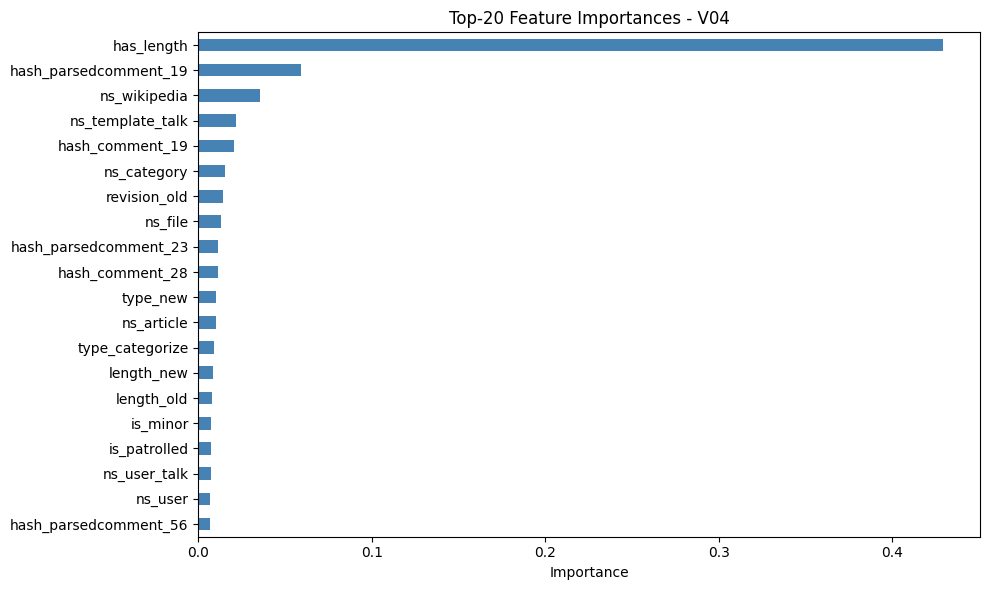

has_length               0.429022
hash_parsedcomment_19    0.059317
ns_wikipedia             0.035633
ns_template_talk         0.021915
hash_comment_19          0.020754
ns_category              0.015203
revision_old             0.014216
ns_file                  0.012816
hash_parsedcomment_23    0.011520
hash_comment_28          0.011471
type_new                 0.010365
ns_article               0.010040
type_categorize          0.008866
length_new               0.008197
length_old               0.008105
is_minor                 0.007267
is_patrolled             0.007069
ns_user_talk             0.007065
ns_user                  0.007003
hash_parsedcomment_56    0.006880


In [17]:
feat_imp = pd.Series(
    best_model.feature_importances_,
    index=fe.get_feature_names(),
).sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 6))
feat_imp[::-1].plot.barh(ax=ax, color='steelblue')
ax.set_title(f'Top-20 Feature Importances - {best_variant}')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()
print(feat_imp.to_string())

## 9b. SHAP Values — Verifying Feature Importance
The gain-based importance metric in the XGBoost model favors features used near the root of the tree (since they affect a larger number of samples), which may overestimate their apparent impact. SHAP (SHapley Additive exPlanations) assigns each feature its **marginal contribution to a specific prediction**, regardless of its position in the tree.

Question: Does `has_length` still dominate after SHAP, or was the profit-based significance an artifact?

Baseline (bias): 0.299 log-odds  ->  P=0.574
Top-20 SHAP vs gain:
                       shap_rank  mean_abs_shap  gain_rank  rank_change
hash_parsedcomment_19          1       0.646314          2            1
hash_parsedcomment_23          2       0.632101          9            7
ns_article                     3       0.419606         12            9
hash_comment_19                4       0.415336          5            1
hour_of_day                    5       0.393267         74           69
revision_old                   6       0.327918          7            1
hash_parsedcomment_61          7       0.258873         21           14
length_new                     8       0.243315         14            6
hash_parsedcomment_52          9       0.237974         23           14
hash_parsedcomment_29         10       0.230741         42           32
hash_parsedcomment_16         11       0.230067         22           11
hash_parsedcomment_56         12       0.178862         20            

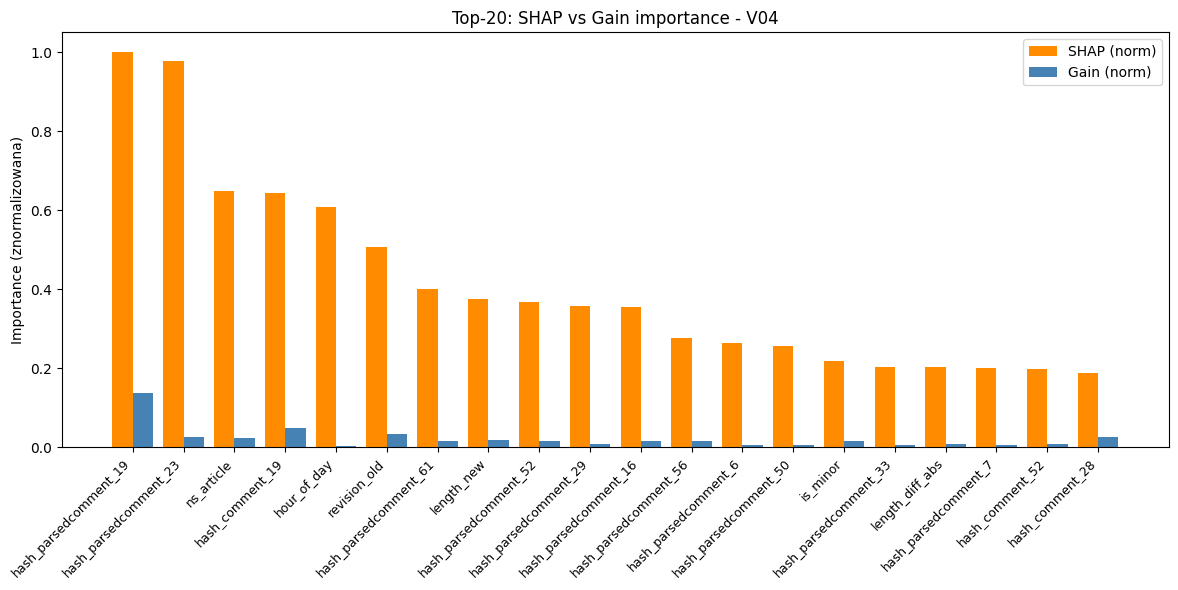

In [18]:
# TreeSHAP przez wbudowane API XGBoosta
booster  = best_model.get_booster()
dmat     = xgb.DMatrix(X_val)
shap_raw = booster.predict(dmat, pred_contribs=True)  # (n, n_features+1)

shap_importance = pd.Series(
    np.abs(shap_raw[:, :-1]).mean(axis=0),
    index=fe.get_feature_names(),
    name="mean_abs_shap",
).sort_values(ascending=False)

bias_mean = shap_raw[:, -1].mean()
print(f"Baseline (bias): {bias_mean:.3f} log-odds  ->  P={1/(1+np.exp(-bias_mean)):.3f}")

# Top-20 porownanie SHAP vs gain
gain_importance = pd.Series(
    best_model.feature_importances_,
    index=fe.get_feature_names(),
    name="gain",
).sort_values(ascending=False)

top20_shap = shap_importance.head(20)
comparison = pd.DataFrame({
    "shap_rank"    : range(1, 21),
    "mean_abs_shap": top20_shap.values,
    "gain_rank"    : [gain_importance.index.get_loc(f) + 1 for f in top20_shap.index],
}, index=top20_shap.index)
comparison["rank_change"] = comparison["gain_rank"] - comparison["shap_rank"]
print("Top-20 SHAP vs gain:")
print(comparison.to_string())

# Wykres side-by-side (znormalizowany do max=1)
shap_norm = top20_shap / top20_shap.max()
gain_norm = gain_importance.reindex(top20_shap.index) / gain_importance.max()

x = np.arange(len(top20_shap))
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - 0.2, shap_norm.values, 0.4, label="SHAP (norm)", color="darkorange")
ax.bar(x + 0.2, gain_norm.values, 0.4, label="Gain (norm)", color="steelblue")
ax.set_xticks(x)
ax.set_xticklabels(top20_shap.index, rotation=45, ha="right", fontsize=9)
ax.set_title(f"Top-20: SHAP vs Gain importance - {best_variant}")
ax.set_ylabel("Importance (znormalizowana)")
ax.legend()
plt.tight_layout()
plt.show()

## 10. Save Model Artifact

In [19]:
best_model.save_model(str(MODEL_PATH))
print(f'Model saved to: {MODEL_PATH}')

loaded = xgb.XGBClassifier()
loaded.load_model(str(MODEL_PATH))
sample_prob = loaded.predict_proba(X_val.iloc[:1])[:, 1][0]
print(f'Reload OK - sample bot probability: {sample_prob:.4f}')
print(f'Best variant: {best_variant}  |  Val AUC: {best_row["val_auc"]:.4f}  |  AUC gap: {best_row["auc_gap"]:.4f}')

Model saved to: D:\Pliki-z-Teams\Przetwarzanie-danych-w-czasie-rzeczywistym\projekt\RTA_ND\models\xgb_bot_detector.json
Reload OK - sample bot probability: 0.0097
Best variant: V04  |  Val AUC: 0.9877  |  AUC gap: 0.0106


## 11. Quick Inference Example

Shows how the streaming consumer (Osoba 4) uses the saved model with the same `feature_engineering.py`.

In [20]:
inference_fe = WikipediaFeatureEngineer()
inference_model = xgb.XGBClassifier()
inference_model.load_model(str(MODEL_PATH))

raw_event = {
    'id': 9999, 'type': 'edit', 'namespace': 0,
    'title': 'Python (programming language)',
    'comment': '/* History */ fixed typo', 'parsedcomment': 'fixed typo',
    'timestamp': 1780600000, 'user': 'SomeEditor', 'bot': False,
    'minor': True, 'patrolled': False,
    'server_name': 'en.wikipedia.org', 'wiki': 'enwiki',
    'length_old': 50000, 'length_new': 50012,
    'revision_old': 1200000, 'revision_new': 1200001,
}

X_live = inference_fe.transform_record(raw_event)
X_live = X_live.reindex(columns=fe.get_feature_names(), fill_value=0)

prob = inference_model.predict_proba(X_live)[:, 1][0]
pred = int(prob >= 0.5)
result_label = 'BOT' if pred else 'HUMAN'
print(f'Bot probability: {prob:.4f}  =>  predicted: {result_label}')

Bot probability: 0.0005  =>  predicted: HUMAN
